
## Minimum Norm Solution






## Inputs



(2, 'i_h2i_rate')

(3, 'i_pci_rate')

(5, 'i_ngi_rate')

(6, 'i_o2_volfract')

(8, 'i_h2_temp')

(9, 'i_hbtemp')

(10, 'i_wind_rt')


## Outputs


* desired output requirements 


(27, 'o_tgt')

(29, 'o_hmt')

(39, 'o_prod_rt')

(40, 'o_fta')



In [1]:

## !pip install xgboost
## !pip install onnxmltools
## !pip install onnxruntime
## !pip install pandas
## !pip install scikit-learn
## !pip install matplotlib
## !pip install seaborn
## !pip install mlxtend
## ! pip install skl2onnx



In [2]:


import torch
import numpy as np
import pandas as pd
import sklearn
import torch.nn as nn
import torch.nn.functional as F

import matplotlib.pyplot as plt
import math
import seaborn as sns
import random
import functorch


import torch.optim as optim


from numpy.random import normal
from scipy.stats import norm
import scipy.stats as stats
from numpy import hstack
from numpy import vstack
from numpy import exp
from sklearn.neighbors import KernelDensity

##from typing import Optional

from torch import Tensor


from torch.utils.data import TensorDataset, DataLoader

from mlxtend.plotting import heatmap

## coefficient of determination (R**2)
from sklearn.metrics import r2_score

np.set_printoptions(suppress=True)
torch.set_printoptions(sci_mode=False)

import os, json, time, uuid


from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score





In [3]:


import xgboost as xgb
from xgboost import XGBClassifier, XGBRegressor, DMatrix, train as train_xgb
from sklearn.datasets import load_boston
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

import onnxmltools
from onnxmltools.convert.xgboost.operator_converters.XGBoost import (
    convert_xgboost)
from onnxmltools.convert import convert_xgboost as convert_xgboost_booster


from zipfile import ZipFile
from skl2onnx.common.data_types import FloatTensorType
from skl2onnx import convert_sklearn, to_onnx, update_registered_converter
from skl2onnx.common.shape_calculator import (
    calculate_linear_classifier_output_shapes,
    calculate_linear_regressor_output_shapes)


# Import the ONNX runtime environment
import onnxruntime as rt




/Users/user/opt/anaconda3/envs/CIVS_py37/lib/python3.7/site-packages/skl2onnx/algebra/onnx_ops.py:159: UserWarning: OpSchema.FormalParameter.typeStr is deprecated and will be removed in 1.16. Use OpSchema.FormalParameter.type_str instead.
  tys = obj.typeStr or ''
/Users/user/opt/anaconda3/envs/CIVS_py37/lib/python3.7/site-packages/skl2onnx/algebra/automation.py:154: UserWarning: OpSchema.FormalParameter.isHomogeneous is deprecated and will be removed in 1.16. Use OpSchema.FormalParameter.is_homogeneous instead.
  if getattr(obj, 'isHomogeneous', False):
/Users/user/opt/anaconda3/envs/CIVS_py37/lib/python3.7/site-packages/jinja2/environment.py:485: UserWarning: OpSchema.FormalParameter.typeStr is deprecated and will be removed in 1.16. Use OpSchema.FormalParameter.type_str instead.
  return getattr(obj, attribute)


In [4]:

import PDFshapingUtils as PDF_tk


In [5]:

PDFshapingOBJ = PDF_tk.PDFshapingUtils()


In [6]:

PDFshapingOBJ.read_csv_file_with_pandas('CFD.16.2025.csv')


In [7]:

## Ty suggested fix where 0 needs to be 300

PDFshapingOBJ.CFD_raw_data["i_h2_temp"] = PDFshapingOBJ.CFD_raw_data["i_h2_temp"].replace(0, 300)


In [8]:

PDFshapingOBJ.CFD_raw_data


,index,case name,i_h2i_rate,i_pci_rate,i_wpi_rate,i_ngi_rate,i_o2_volfract,i_ng_temp,i_h2_temp,i_hbtemp,...,o_h2o_sollos,o_feo_sollos,o_hm_rt,o_mw_rt,o_wf_rt,o_hm_h2share,o_mw_h2share,o_wf_h2share,o_prod_rt,o_fta
0,1,H2-0_PCI-0_WPI-0_NG-120_O2-21_NGT-300_H2T-0_HB...,0,0,0,120,21,300,300,1200,...,20.0,44.9,122.0,264.0,687.0,31.6,26.7,63.5,4050.0,1800.0
1,2,H2-0_PCI-0_WPI-0_NG-100_O2-21_NGT-300_H2T-0_HB...,0,0,0,100,21,300,300,1200,...,18.5,52.6,122.0,265.0,684.0,27.9,23.4,60.6,4060.0,1850.0
2,3,H2-0_PCI-0_WPI-0_NG-100_O2-21_NGT-300_H2T-0_HB...,0,0,0,100,21,300,300,1200,...,19.6,50.9,123.0,266.0,690.0,27.7,23.5,60.8,4080.0,1850.0
3,4,H2-0_PCI-0_WPI-0_NG-100_O2-21_NGT-300_H2T-0_HB...,0,0,0,100,21,300,300,1200,...,19.2,52.2,124.0,268.0,690.0,27.7,23.2,60.6,4090.0,1850.0
4,5,H2-0_PCI-0_WPI-0_NG-100_O2-21_NGT-300_H2T-0_HB...,0,0,0,100,21,300,300,1200,...,19.2,52.4,124.0,268.0,695.0,27.7,23.2,60.7,4110.0,1850.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4994,4995,H2-30_PCI-0_WPI-0_NG-80_O2-30_NGT-300_H2T-300_...,30,0,0,80,30,300,300,1600,...,18.7,40.3,353.0,763.0,2190.0,34.0,20.5,56.7,11700.0,2380.0
4995,4996,H2-30_PCI-0_WPI-0_NG-80_O2-30_NGT-300_H2T-300_...,30,0,0,80,30,300,300,1480,...,18.7,40.7,353.0,763.0,2190.0,33.8,20.4,56.8,11700.0,2310.0
4996,4997,H2-30_PCI-0_WPI-0_NG-80_O2-30_NGT-300_H2T-300_...,30,0,0,80,30,300,300,1600,...,19.2,37.5,353.0,763.0,2230.0,33.6,20.4,57.1,11700.0,2380.0
4997,4998,H2-30_PCI-0_WPI-0_NG-80_O2-30_NGT-300_H2T-300_...,30,0,0,80,30,300,300,1480,...,17.6,39.8,355.0,768.0,2220.0,34.0,20.0,55.7,11800.0,2310.0


In [9]:

PDFshapingOBJ.print_headers_list()


['index', 'case name', 'i_h2i_rate', 'i_pci_rate', 'i_wpi_rate', 'i_ngi_rate', 'i_o2_volfract', 'i_ng_temp', 'i_h2_temp', 'i_hbtemp', 'i_wind_rt', 'i_blastH2O', 'i_BdnH2O', 'i_sgi_rate', 'i_sgtemp', 'i_sgi_H2COratio', 'i_sgi_ReProRatio', 'o_tuy_velo', 'o_tuy_temp', 'o_burn', 'o_delp', 'o_co_vf', 'o_co2_vf', 'o_h2_vf', 'o_n2_vf', 'o_co_util', 'o_h2_util', 'o_tgt', 'o_coke_rt', 'o_hmt', 'o_co2_sollos', 'o_h2o_sollos', 'o_feo_sollos', 'o_hm_rt', 'o_mw_rt', 'o_wf_rt', 'o_hm_h2share', 'o_mw_h2share', 'o_wf_h2share', 'o_prod_rt', 'o_fta']
41
(0, 'index')
(1, 'case name')
(2, 'i_h2i_rate')
(3, 'i_pci_rate')
(4, 'i_wpi_rate')
(5, 'i_ngi_rate')
(6, 'i_o2_volfract')
(7, 'i_ng_temp')
(8, 'i_h2_temp')
(9, 'i_hbtemp')
(10, 'i_wind_rt')
(11, 'i_blastH2O')
(12, 'i_BdnH2O')
(13, 'i_sgi_rate')
(14, 'i_sgtemp')
(15, 'i_sgi_H2COratio')
(16, 'i_sgi_ReProRatio')
(17, 'o_tuy_velo')
(18, 'o_tuy_temp')
(19, 'o_burn')
(20, 'o_delp')
(21, 'o_co_vf')
(22, 'o_co2_vf')
(23, 'o_h2_vf')
(24, 'o_n2_vf')
(25, 'o_co_ut

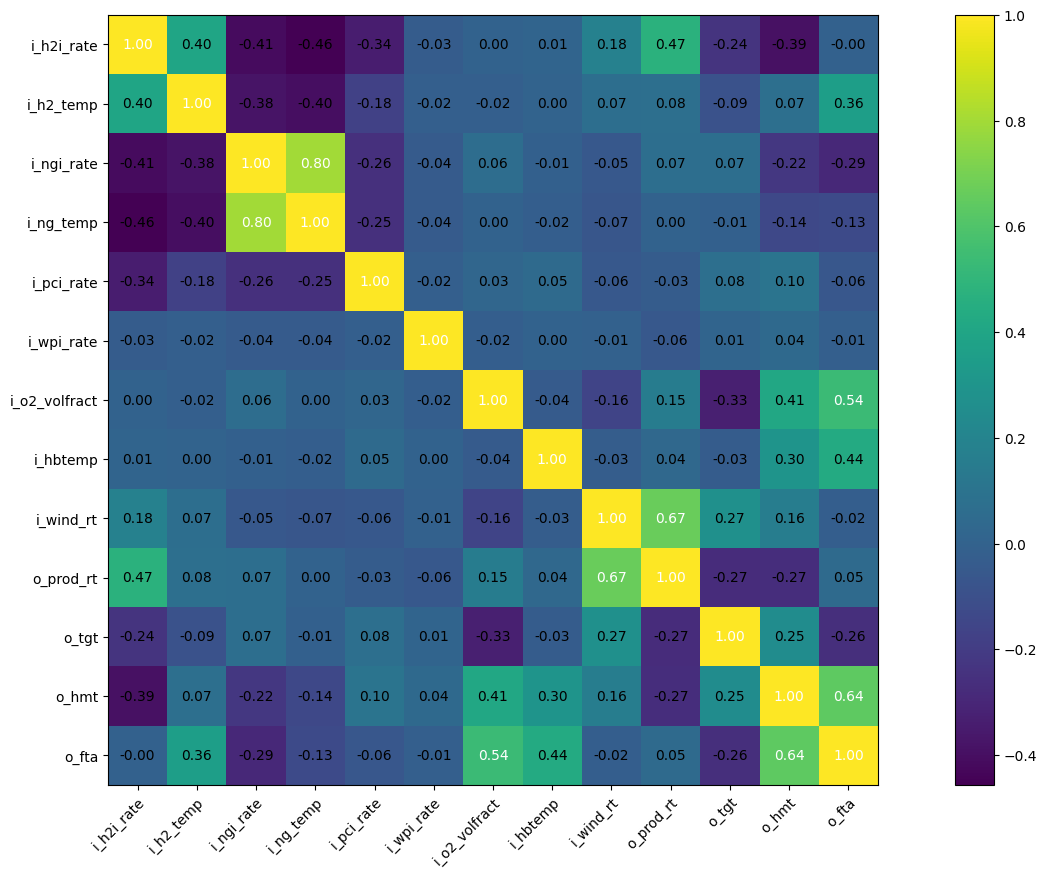

In [10]:


PDFshapingOBJ.list_of_selected_column_names = ['i_h2i_rate','i_h2_temp','i_ngi_rate','i_ng_temp','i_pci_rate',
                    'i_wpi_rate','i_o2_volfract',
                    'i_hbtemp','i_wind_rt','o_prod_rt', 'o_tgt', 'o_hmt','o_fta']



PDFshapingOBJ.print_correlation_coefficients()


In [11]:

PDFshapingOBJ.convert_pd_data_to_numpy()


[[1
  'H2-0_PCI-0_WPI-0_NG-120_O2-21_NGT-300_H2T-0_HBT-1200_WR-195_MHB-5.7_BM-7_SGI-0_SGT-0_SGC_0 '
  0 ... 63.5 4050.0 1800.0]
 [2
  'H2-0_PCI-0_WPI-0_NG-100_O2-21_NGT-300_H2T-0_HBT-1200_WR-195_MHB-5.7_BM-1_SGI-0_SGT-0_SGC_0 '
  0 ... 60.6 4060.0 1850.0]
 [3
  'H2-0_PCI-0_WPI-0_NG-100_O2-21_NGT-300_H2T-0_HBT-1200_WR-195_MHB-5.7_BM-5_SGI-0_SGT-0_SGC_0 '
  0 ... 60.8 4080.0 1850.0]
 ...
 [4997
  'H2-30_PCI-0_WPI-0_NG-80_O2-30_NGT-300_H2T-300_HBT-1600_WR-230_MHB-5.7_BM-5_SGI-0_SGT-0_SGC_0 '
  30 ... 57.1 11700.0 2380.0]
 [4998
  'H2-30_PCI-0_WPI-0_NG-80_O2-30_NGT-300_H2T-300_HBT-1480_WR-230_MHB-5.7_BM-3_SGI-0_SGT-0_SGC_0 '
  30 ... 55.7 11800.0 2310.0]
 [4999
  'H2-30_PCI-0_WPI-0_NG-80_O2-30_NGT-300_H2T-300_HBT-1480_WR-230_MHB-5.7_BM-5_SGI-0_SGT-0_SGC_0 '
  30 ... 56.2 11800.0 2310.0]]
(4999, 41)


In [12]:

PDFshapingOBJ.gen_X_y_for_selected_indeces(  
                   inputs = [  2, 3, 5, 6, 8, 9, 10   ] , 
                   outputs= [ 27, 29, 39, 40 ]   
)


## inputs = [ 2, 3, 5, 6, 8, 9, 10  ]          ## the full 7



7
4


In [13]:

print(PDFshapingOBJ.X.shape)
print(PDFshapingOBJ.y.shape)


(4999, 7)
(4999, 4)


In [14]:

PDFshapingOBJ.random_seed = int( random.random() * 100  )         ## defautl is 42


In [15]:

PDFshapingOBJ.split_np_data_train_test(selected_test_size=0.2)


(3999, 7)
(1000, 7)
(3999, 4)
(1000, 4)


In [16]:

print(PDFshapingOBJ.X_train.shape)
print(PDFshapingOBJ.X_test.shape)

print(PDFshapingOBJ.y_train.shape)
print(PDFshapingOBJ.y_test.shape)


(3999, 7)
(1000, 7)
(3999, 4)
(1000, 4)


In [17]:

from sklearn.decomposition import PCA

# Instantiate PCA to reduce to 4 components
pca = PCA(n_components=4)

# Fit on training data and transform both train and test
X_train_pca = pca.fit_transform(PDFshapingOBJ.X_train)
X_test_pca  = pca.transform(PDFshapingOBJ.X_test)

# Replace the original inputs with PCA-reduced versions
PDFshapingOBJ.X_train = X_train_pca
PDFshapingOBJ.X_test  = X_test_pca





In [18]:

print(PDFshapingOBJ.X_train.shape)
print(PDFshapingOBJ.X_test.shape)

print(PDFshapingOBJ.y_train.shape)
print(PDFshapingOBJ.y_test.shape)


(3999, 4)
(1000, 4)
(3999, 4)
(1000, 4)


In [19]:

PDFshapingOBJ.convert_dataset_from_np_to_torch()


In [20]:

PDFshapingOBJ.standardize_X_scales()
PDFshapingOBJ.standardize_y_scales()


In [21]:


PDFshapingOBJ.gen_Dataloader_train()

PDFshapingOBJ.train_dl



## Model Forward ( 7x4 )


In [22]:

n_inputs  = 4     ## 7
n_outputs = 4




#############################################################
##   F1      plus       F2
## Linear     +      Nonlinear

class F1plusF2_SIO_Forward(nn.Module):
    ## initialize the layers
    def __init__(self, x_means, x_deviations, y_means, y_deviations,  device='cuda'):
        super().__init__()
        self.device = device
        
        ## self.x_means      = x_means
        ## self.x_deviations = x_deviations
        ## self.y_means      = y_means
        ## self.y_deviations = y_deviations
        
        
        self.x_means      = x_means.to(self.device)
        self.x_deviations = x_deviations.to(self.device)
        self.y_means      = y_means.to(self.device)
        self.y_deviations = y_deviations.to(self.device)
        
        
        
        ## F1
        self.f1_linear1 = nn.Linear(n_inputs, n_outputs)       
        
        ## F2
        self.f2_linear1 = nn.Linear(n_inputs, 10)
        self.f2_act1    = nn.Sigmoid()                    ## Tanh()                       
        self.f2_linear2 = nn.Linear(10, n_outputs)       
        self.f2_dropout = nn.Dropout(0.25)
        
        # Move model to device
        self.to(self.device)
        
        
    ## perform inference
    def forward(self, x):
        x = x.to(self.device)
        x = (x - self.x_means) / self.x_deviations
        
        ## F1
        f1 = self.f1_linear1(x)
        
        ## F2
        f2 = self.f2_linear1(x)
        f2 = self.f2_act1(f2)
        f2 = self.f2_dropout(f2)
        f2 = self.f2_linear2(f2)
        
        
        y_scaled   = f1 + f2
        y_descaled = y_scaled * self.y_deviations + self.y_means
        
        ##   y_descaled = torch.clamp(  y_descaled, min=0.0  )
        
        return y_descaled, y_scaled
    




In [23]:

n_inputs  = 4     ## 7
n_outputs = 4





    
class ResidualNet_Forward(nn.Module):
    def __init__(self, x_means, x_deviations, y_means, y_deviations, dropout_rate=0.1, device='cuda'):
        
        super().__init__()
        self.device = device
        
        self.x_means      = x_means.to(self.device)
        self.x_deviations = x_deviations.to(self.device)
        self.y_means      = y_means.to(self.device)
        self.y_deviations = y_deviations.to(self.device)

     
        self.fc1  = nn.Linear(n_inputs, 64)
        self.act1 = nn.ReLU()
        self.dropout1 = nn.Dropout(dropout_rate)

        self.fc2 = nn.Linear(64, 64)
        self.act2 = nn.ReLU()
        self.dropout2 = nn.Dropout(dropout_rate)

        self.fc3 = nn.Linear(64, n_outputs)

        # If input_dim ≠ 64, project for residual addition
        self.input_proj = nn.Linear(n_inputs, 64) if n_inputs != 64 else nn.Identity()
        
        # Move model to device
        self.to(self.device)
        

    def forward(self, x):
        x  = x.to(self.device)
        x  = (x - self.x_means) / self.x_deviations
        x0 = self.input_proj(x)
        x1 = self.dropout1(self.act1(self.fc1(x)))
        x2 = self.dropout2(self.act2(self.fc2(x1)))
        x_res = x2 + x0
        y_scaled = self.fc3(x_res)
        y_descaled = y_scaled * self.y_deviations + self.y_means
        
        return y_descaled, y_scaled
    

    


In [24]:

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

## model_Forward     = F1plusF2_SIO_Forward(

model_Forward     =     F1plusF2_SIO_Forward(
                         PDFshapingOBJ.x_means, 
                         PDFshapingOBJ.x_deviations, 
                         PDFshapingOBJ.y_means, 
                         PDFshapingOBJ.y_deviations,
                         device=device  # pass device into the model
    
)

optimizer = optim.Adam(model_Forward.parameters(), lr=0.001)
loss_fn   = nn.MSELoss()



In [25]:

model_Forward.train()

for epoch in range(1000):
    for xb, yb in PDFshapingOBJ.train_dl:
        
        xb = xb.to(model_Forward.device)
        yb = yb.to(model_Forward.device)
        
        optimizer.zero_grad()
        pred_descaled, pred_scaled = model_Forward(xb)
        loss = loss_fn(pred_scaled, yb)
        loss.backward()
        optimizer.step()
    if epoch % 100 == 0:
        print(epoch, ".....", loss.item() ) 
    



0 ..... 0.7783666849136353
100 ..... 0.5453787446022034
200 ..... 0.7401800155639648
300 ..... 0.6540752053260803
400 ..... 0.7252758145332336
500 ..... 0.567977249622345
600 ..... 0.5073724389076233
700 ..... 0.44452986121177673
800 ..... 0.5033443570137024
900 ..... 0.5763235688209534


In [26]:

print("=== SANITY CHECK: SCALING ===")
print("y_means:", PDFshapingOBJ.y_means)
print("y_deviations:", PDFshapingOBJ.y_deviations)

print("===============================================")

print("x_means:", PDFshapingOBJ.x_means)
print("x_deviations:", PDFshapingOBJ.x_deviations)


=== SANITY CHECK: SCALING ===
y_means: tensor([[  97.8878, 1292.4460, 8446.5898, 2307.1396]])
y_deviations: tensor([[  50.8324,  525.5093, 1510.8268,  211.5773]])
x_means: tensor([[    -0.0000,     -0.0000,      0.0000,     -0.0000]])
x_deviations: tensor([[274.8051, 157.3820,  51.0626,  35.9985]])


In [27]:

print(PDFshapingOBJ.y_means -  PDFshapingOBJ.y_deviations)
print(PDFshapingOBJ.y_means +  PDFshapingOBJ.y_deviations)


tensor([[  47.0554,  766.9368, 6935.7632, 2095.5623]])
tensor([[ 148.7202, 1817.9553, 9957.4170, 2518.7170]])


In [28]:

print(PDFshapingOBJ.x_means -  PDFshapingOBJ.x_deviations)
print(PDFshapingOBJ.x_means +  PDFshapingOBJ.x_deviations)


tensor([[-274.8051, -157.3820,  -51.0626,  -35.9985]])
tensor([[274.8051, 157.3820,  51.0626,  35.9985]])



## Is model  invertible ?

* use the Jacobian


In [29]:

import torch
from torch.autograd.functional import jacobian


In [30]:

## x = torch.randn(1, 7, requires_grad=True)

x = torch.randn(      7, requires_grad=True)  # shape [7]

x = torch.randn(      4, requires_grad=True)  # shape [7]


In [31]:

def wrapped_model(x):
    y_descaled, _ = model_Forward(x)
    return y_descaled  # Only return 1 tensor to get a clean Jacobian




In [32]:

## J = jacobian(model_Forward, x)

J = jacobian(wrapped_model, x)


In [33]:

print( len(J) )


1


In [34]:


print( J.shape )  # Should be [1, 4, 7]


torch.Size([1, 4, 4])


In [35]:

u, s, v = torch.svd(J)  


In [36]:

rank = (s > 1e-5).sum()


In [37]:


print("Local Jacobian rank:", rank.item())


Local Jacobian rank: 4



## Example of Min Norm Solution



## Approach


In [38]:

import numpy as np
from numpy.linalg import norm

# --- distance function ---
def euclid(a, b):
    return norm(a - b)


In [39]:


def solve_minimum_norm_update( x0, target_y):
   
    
    # Ensure the input requires gradients

    x = x0.detach().clone().requires_grad_(True)
    

    # Compute the Jacobian matrix at the current input x
    # 'create_graph=True' is often needed if you want to backpropagate through this process
    
    J = jacobian(wrapped_model, x, create_graph=True, vectorize=True)
    
    # Calculate the current residual (difference between desired and actual output)
    current_y = wrapped_model(x)
    delta_y   = target_y - current_y
    
    print( J.shape )
    
    # Flatten the Jacobian and residual if necessary (depends on problem dimensions)
    # This example assumes J is 2D and delta_y is 1D for simplicity
    if J.dim() > 2:
        J = J.view(-1, x.numel())
        delta_y = delta_y.view(-1)
        
    # Compute the pseudoinverse of the Jacobian using SVD
    ####################################
    #J_pinv = torch.pinverse(J)
    
    thresholdSVD = 1e-2   ## 1e-2
    U, S, Vt = torch.linalg.svd(J)
    S_inv = torch.where(S > thresholdSVD, 1.0/S, torch.zeros_like(S))
    J_pinv = Vt.T @ torch.diag(S_inv) @ U.T

    
    ####################################
    
    # Calculate the minimum norm update: Delta x = J_pinv @ Delta y
    ## delta_x = J_pinv @ delta_y
    delta_x = 0.01 * (J_pinv @ delta_y)    ## 0.01

    
    # Reshape delta_x to match the original input shape
    delta_x = delta_x.view_as(x0)
    
    return delta_x







In [40]:



x_starting_point = torch.tensor(   PDFshapingOBJ.X_test[0]   )    ## starting point

dist_method_A = []


for i in range(  1, PDFshapingOBJ.X_test.shape[0]  ):
    
    target_y  = torch.tensor( PDFshapingOBJ.y_test[i]   )    ## what you want y ?
    x_real    = torch.tensor( PDFshapingOBJ.X_test[i]   )    ## real x
    
    x_temp    = x_starting_point
    
    for j in range(5):
        
        delta_x  = solve_minimum_norm_update( x_temp, target_y )
        x_temp   = x_temp + delta_x
        
        
    x_new             = x_temp  
    
    x_new_np          =  x_new.detach().numpy()
    x_real_np         = x_real.detach().numpy()
    
    x_new_solution    = pca.inverse_transform( x_new_np   )
    x_real_np_sol     = pca.inverse_transform( x_real_np  ) 
    
    
    # enforce physical constraint
    x_new_solution = np.maximum(x_new_solution, 0.0)
    x_real_np_sol  = np.maximum(x_real_np_sol,  0.0)
    
    
    the_cols = "    i_h2i_rate,   i_pci_rate,   i_ngi_rate,i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt"
    

    print( the_cols )
    print( "pred" )
    print( x_new_solution )
    print( "real" )
    print( x_real_np_sol )
    
    dist_method_A.append( euclid(x_new_np, x_real_np) )
    
    print(i)
    print('********************************')



torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
    i_h2i_rate,   i_pci_rate,   i_ngi_rate,i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt
pred
[   3.45210812    2.33555532  104.7134655    25.77992231  259.58092204
 1506.64156234  195.06630261]
real
[   0.53071511  127.87727225    2.6655619    25.74798138  300.04195298
 1480.09421836  192.37995369]
1
********************************
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
    i_h2i_rate,   i_pci_rate,   i_ngi_rate,i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt
pred
[   7.32671978    2.29425749   84.17542119   25.71538213  332.12991396
 1460.85071274  196.72794988]
real
[   4.22321273   83.66786125   23.46867765   25.67357391  300.01994653
 1480.08883439  194.52559456]
2
********************************
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1,

torch.Size([1, 4, 4])
    i_h2i_rate,   i_pci_rate,   i_ngi_rate,i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt
pred
[   3.64062488    1.55539307  106.37909756   25.83533042  322.11499212
 1483.10126412  194.99016548]
real
[  21.69879153    0.            0.           25.33164373  299.953836
 1199.91785476  204.68504147]
30
********************************
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
    i_h2i_rate,   i_pci_rate,   i_ngi_rate,i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt
pred
[   2.94510206    2.12916993  108.97962964   25.84363349  298.64771958
 1484.22862212  194.76471779]
real
[  10.43625942    0.           68.60300348   25.56466065  300.06823589
 1480.04214253  198.24434253]
31
********************************
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
    i_h2i_rate,   i_pci_rate,   i_ngi_rate,i_o2_volfract,    i_h2_temp, i_hbtemp

torch.Size([1, 4, 4])
    i_h2i_rate,   i_pci_rate,   i_ngi_rate,i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt
pred
[   3.08116555    2.72580086  106.01963615   25.78520508  247.5086642
 1506.30703843  194.94748927]
real
[  20.52440056    4.03290765    4.12152167   25.19105976  299.87022144
 1447.96171597  202.95774705]
53
********************************
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
    i_h2i_rate,   i_pci_rate,   i_ngi_rate,i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt
pred
[   3.78061832    2.13451829  101.22639164   25.74218296  217.71795665
 1500.29626167  195.43359509]
real
[   4.93892936    0.81700776  100.849211     25.68743868  299.96609741
 1599.98595642  195.15889417]
54
********************************
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
    i_h2i_rate,   i_pci_rate,   i_ngi_rate,i_o2_volfract,    i_h2_temp, i_hbtem

    i_h2i_rate,   i_pci_rate,   i_ngi_rate,i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt
pred
[   5.10785213    1.16932122  106.25618384   25.99639256  558.88435582
 1416.16870858  194.91965839]
real
[  10.09018681    4.88834211   64.69209768   25.56840588  299.98099098
 1480.0880809   198.02242176]
93
********************************
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
    i_h2i_rate,   i_pci_rate,   i_ngi_rate,i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt
pred
[   4.06930574    1.00945698  103.59273634   25.79071901  295.03615976
 1496.57638775  195.25104752]
real
[   0.          146.4327252     0.           25.79751706  299.9570958
 1479.88730144  191.26378149]
94
********************************
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
    i_h2i_rate,   i_pci_rate,   i_ngi_rate,i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt
pred
[   

    i_h2i_rate,   i_pci_rate,   i_ngi_rate,i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt
pred
[   4.62664969    1.61854763  102.79756229   25.87080618  393.64344952
 1451.67930907  195.26663677]
real
[  23.6367047     0.            0.           24.97485499  300.18937197
 1600.11284174  203.76787169]
117
********************************
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
    i_h2i_rate,   i_pci_rate,   i_ngi_rate,i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt
pred
[   1.1049875     1.29272283  123.9374886    25.928003    363.29549756
 1531.86537769  193.42654943]
real
[  14.05373085    0.           41.15413721   25.6230951   299.8669029
 1199.86490049  201.16562843]
118
********************************
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
    i_h2i_rate,   i_pci_rate,   i_ngi_rate,i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt
pred
[ 

...

torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
    i_h2i_rate,   i_pci_rate,   i_ngi_rate,i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt
pred
[   5.98866705    0.31255372   92.16933817   25.73139502  285.5079997
 1468.11559591  196.30927726]
real
[  25.93834317    0.            0.           25.10229585  600.05875335
 1599.96488249  203.50178278]
862
********************************
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
    i_h2i_rate,   i_pci_rate,   i_ngi_rate,i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt
pred
[   5.8195791     1.11318961   91.93742574   25.72373605  271.89804564
 1472.62290757  196.26350979]
real
[  24.00905854    0.            0.           24.96249488  300.0724578
 1599.97238237  203.95268305]
863
********************************
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
    i_h2i_ra

torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
    i_h2i_rate,   i_pci_rate,   i_ngi_rate,i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt
pred
[   5.48152899    0.95686847   94.69080673   25.76642236  296.15360307
 1455.62987391  196.07990147]
real
[  13.85228302    0.           54.78527512   25.35395073  300.06571736
 1599.96144699  199.30452635]
901
********************************
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
    i_h2i_rate,   i_pci_rate,   i_ngi_rate,i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt
pred
[   5.20317445    1.43488279   91.38269842   25.64042207  157.6453409
 1507.53580952  196.32620615]
real
[   0.          173.46485094    0.           25.93874878  300.03564237
 1479.99772479  188.81083581]
902
********************************
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size(

torch.Size([1, 4, 4])
    i_h2i_rate,   i_pci_rate,   i_ngi_rate,i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt
pred
[   6.61905152    1.46444265   83.95516622   25.58217852  170.53433812
 1525.70199574  196.83460882]
real
[  22.41353104    0.            0.05444454   25.01673126  299.8823269
 1599.87334895  203.17553907]
928
********************************
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
    i_h2i_rate,   i_pci_rate,   i_ngi_rate,i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt
pred
[   4.74394478    1.83894345   94.82755593   25.67695521  186.35169328
 1508.99382789  195.97760124]
real
[  11.50468271    0.581665     60.57343236   25.52064694  299.99642911
 1480.00364746  198.71493616]
929
********************************
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
    i_h2i_rate,   i_pci_rate,   i_ngi_rate,i_o2_volfract,    i_h2_temp, i_hbt

torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
    i_h2i_rate,   i_pci_rate,   i_ngi_rate,i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt
pred
[   1.40129746    2.42626204  118.99887645   25.89268054  316.6779523
 1516.22431474  193.82879946]
real
[   0.46847824    0.07583547  120.08125515   26.14543693  299.99714132
 1199.99758603  194.93880671]
965
********************************
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
    i_h2i_rate,   i_pci_rate,   i_ngi_rate,i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt
pred
[   4.50295258    0.82505968  103.23019457   25.81996414  349.87894714
 1487.52999888  195.24927135]
real
[  25.20206141    0.            0.           25.41796705  600.13585547
 1199.99939453  205.00089258]
966
********************************
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
    i_h2i_r

torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
    i_h2i_rate,   i_pci_rate,   i_ngi_rate,i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt
pred
[   4.44686339    2.57503808  101.59232007   25.82041738  345.34389255
 1481.60981011  195.25268288]
real
[  25.01152314    3.06231766    3.11505307   25.42604983  899.90632882
 1479.97741763  202.21350321]
984
********************************
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
    i_h2i_rate,   i_pci_rate,   i_ngi_rate,i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt
pred
[   3.35445105    3.24937485  105.97176076   25.81563304  301.58002413
 1501.96749429  194.84698652]
real
[  26.94080893    3.34007283    3.40986675   25.56585079 1199.89266999
 1479.96992157  201.76260328]
985
********************************
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
    i_h2i_rate,   i_pci_rate,   

In [41]:

avg_A = np.mean(dist_method_A)


print("Average Euclidean Distance:")
print("Method A:", avg_A)


Average Euclidean Distance:
Method A: 251.34511



## Now add Costs


In [42]:

price_real = np.array([4.0, 1.0, 0.5, 0.0, 0.0, 0.0, 0.0])

price_latent = pca.components_ @ price_real

price_latent = torch.tensor(price_latent, dtype=torch.float32)


In [43]:

def solve_minimum_norm_update( x0, target_y):
   
    
    # Ensure the input requires gradients

    x = x0.detach().clone().requires_grad_(True)
    

    # Compute the Jacobian matrix at the current input x
    # 'create_graph=True' is often needed if you want to backpropagate through this process
    
    J = jacobian(wrapped_model, x, create_graph=True, vectorize=True)
    
    # Calculate the current residual (difference between desired and actual output)
    current_y = wrapped_model(x)
    delta_y   = target_y - current_y
    
    print( J.shape )
    
    # Flatten the Jacobian and residual if necessary (depends on problem dimensions)
    # This example assumes J is 2D and delta_y is 1D for simplicity
    if J.dim() > 2:
        J = J.view(-1, x.numel())
        delta_y = delta_y.view(-1)
        
    # Compute the pseudoinverse of the Jacobian using SVD
    ####################################
    #J_pinv = torch.pinverse(J)
    
    thresholdSVD = 1e-2   ## 1e-2
    U, S, Vt = torch.linalg.svd(J)
    S_inv = torch.where(S > thresholdSVD, 1.0/S, torch.zeros_like(S))
    J_pinv = Vt.T @ torch.diag(S_inv) @ U.T

    
    ####################################
    
    # Calculate the minimum norm update: Delta x = J_pinv @ Delta y
    ## delta_x = J_pinv @ delta_y
    ##delta_x = 0.01 * (J_pinv @ delta_y)    ## 0.01
    
    lambda_cost = 0.01
    
    delta_x = (J_pinv @ delta_y) - lambda_cost * price_latent
    delta_x = 0.01 * delta_x

    
    # Reshape delta_x to match the original input shape
    delta_x = delta_x.view_as(x0)
    
    return delta_x






In [44]:


x_starting_point = torch.tensor(   PDFshapingOBJ.X_test[0]   )    ## starting point

dist_method_A = []
cost_diffs    = [] 
cost_diff     = 0

percent_diffs = []
percent_diff  = 0 


for i in range(  1, PDFshapingOBJ.X_test.shape[0]  ):
    
    target_y  = torch.tensor( PDFshapingOBJ.y_test[i]   )    ## what you want y ?
    x_real    = torch.tensor( PDFshapingOBJ.X_test[i]   )    ## real x
    
    x_temp    = x_starting_point
    
    for j in range(5):
        
        delta_x  = solve_minimum_norm_update( x_temp, target_y )
        x_temp   = x_temp + delta_x
        
        # ---- compute cost at this iteration ----
        x_temp_np = x_temp.detach().numpy()
        x_temp_real = pca.inverse_transform(x_temp_np)

        # enforce physical constraint
        x_temp_real = np.maximum(x_temp_real, 0.0)

        cost = np.dot(price_real, x_temp_real)
        
        x_real_np         = x_real.detach().numpy()
        x_real_np_sol     = pca.inverse_transform( x_real_np  ) 
        cost_real         = np.dot(price_real, x_real_np_sol)
       
        print(f"iteration {j} cost: {cost}...H2, PCI, NGI:", x_temp_real[:3] )
        print("real cost       :", cost_real)
        cost_diff    = cost - cost_real
        percent_diff = (cost - cost_real) / cost_real
        
    percent_diffs.append( percent_diff  )
          
    cost_diffs.append(       cost_diff  )
        
        
        
        
        
    x_new             = x_temp  
    
    x_new_np          =  x_new.detach().numpy()
    x_real_np         = x_real.detach().numpy()
    
    x_new_solution    = pca.inverse_transform( x_new_np   )
    x_real_np_sol     = pca.inverse_transform( x_real_np  ) 
    
    
    # enforce physical constraint
    x_new_solution = np.maximum(x_new_solution, 0.0)
    x_real_np_sol  = np.maximum(x_real_np_sol,  0.0)
    
    
    the_cols = "    i_h2i_rate,   i_pci_rate,   i_ngi_rate,i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt"
    

    print("...")
    print("...")
    print("...")
    print( the_cols )
    print( "pred" )
    print( x_new_solution )
    print( "real" )
    print( x_real_np_sol )
    
    dist_method_A.append( euclid(x_new_np, x_real_np) )
    
    print(i)
    print('********************************')




torch.Size([1, 4, 4])
iteration 0 cost: 69.9592771989663...H2, PCI, NGI: [ 4.59738651  1.89483586 99.34979063]
real cost       : 131.33291365262292
torch.Size([1, 4, 4])
iteration 1 cost: 69.71492073950026...H2, PCI, NGI: [ 4.45349648  1.93998895 99.92189177]
real cost       : 131.33291365262292
torch.Size([1, 4, 4])
iteration 2 cost: 69.54725879101366...H2, PCI, NGI: [  4.34406073   1.98806923 100.36589333]
real cost       : 131.33291365262292
torch.Size([1, 4, 4])
iteration 3 cost: 69.30555511306129...H2, PCI, NGI: [  4.18297363   2.06680411 101.01371297]
real cost       : 131.33291365262292
torch.Size([1, 4, 4])
iteration 4 cost: 69.06167451123143...H2, PCI, NGI: [  4.04650048   2.09370841 101.56392833]
real cost       : 131.33291365262292
...
...
...
    i_h2i_rate,   i_pci_rate,   i_ngi_rate,i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt
pred
[   4.04650048    2.09370841  101.56392833   25.76673766  265.20440774
 1499.20713087  195.34994001]
real
[   0.53071511  127.87727225    

torch.Size([1, 4, 4])
iteration 2 cost: 70.28529435396452...H2, PCI, NGI: [  4.3305779    2.06503203 101.79590142]
real cost       : 87.74328016729508
torch.Size([1, 4, 4])
iteration 3 cost: 70.54897286108366...H2, PCI, NGI: [  4.48574807   2.04828183 101.11539753]
real cost       : 87.74328016729508
torch.Size([1, 4, 4])
iteration 4 cost: 70.78879458879483...H2, PCI, NGI: [  4.63881861   1.99603777 100.47496476]
real cost       : 87.74328016729508
...
...
...
    i_h2i_rate,   i_pci_rate,   i_ngi_rate,i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt
pred
[   4.63881861    1.99603777  100.47496476   25.83135513  343.74556653
 1455.51961988  195.47239342]
real
[  21.58090441    0.9645525     0.91022008   25.15515511  299.99884753
 1448.02440475  203.47237862]
12
********************************
torch.Size([1, 4, 4])
iteration 0 cost: 69.58071531239048...H2, PCI, NGI: [  4.23908129   1.8196133  101.60955368]
real cost       : 79.78176599093928
torch.Size([1, 4, 4])
iteration 1 cost: 69.4

torch.Size([1, 4, 4])
iteration 3 cost: 69.49545750965967...H2, PCI, NGI: [ 5.34754964  1.10712877 93.99626041]
real cost       : 77.9501053992974
torch.Size([1, 4, 4])
iteration 4 cost: 69.151505006021...H2, PCI, NGI: [ 5.25713836  1.05089919 94.14410472]
real cost       : 77.9501053992974
...
...
...
    i_h2i_rate,   i_pci_rate,   i_ngi_rate,i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt
pred
[   5.25713836    1.05089919   94.14410472   25.72697715  244.10841413
 1470.69657521  196.13864573]
real
[  12.79577892    0.           57.99657757   25.3898554   299.93709902
 1599.89876105  198.78989461]
24
********************************
torch.Size([1, 4, 4])
iteration 0 cost: 70.8968379367654...H2, PCI, NGI: [ 5.56362359  1.60083839 94.08301034]
real cost       : 77.99217633102477
torch.Size([1, 4, 4])
iteration 1 cost: 71.77163329630307...H2, PCI, NGI: [ 6.63633121  1.28637616 87.8798646 ]
real cost       : 77.99217633102477
torch.Size([1, 4, 4])
iteration 2 cost: 71.71397760538721...H

torch.Size([1, 4, 4])
iteration 2 cost: 70.41548712236188...H2, PCI, NGI: [ 4.7315596   1.67962433 99.61924881]
real cost       : 101.21463330353238
torch.Size([1, 4, 4])
iteration 3 cost: 70.71202428408623...H2, PCI, NGI: [ 4.91328556  1.65999014 98.7977838 ]
real cost       : 101.21463330353238
torch.Size([1, 4, 4])
iteration 4 cost: 71.00556067697462...H2, PCI, NGI: [ 5.09312144  1.64064912 97.98485159]
real cost       : 101.21463330353238
...
...
...
    i_h2i_rate,   i_pci_rate,   i_ngi_rate,i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt
pred
[   5.09312144    1.64064912   97.98485159   25.807103    337.26779847
 1459.29169325  195.6957496 ]
real
[   4.99702789   60.80851276   40.83601799   25.67882487  299.96428365
 1479.98814071  195.11553444]
32
********************************
torch.Size([1, 4, 4])
iteration 0 cost: 69.43001930784541...H2, PCI, NGI: [  4.07624117   2.01053747 102.22903431]
real cost       : 113.65220650509067
torch.Size([1, 4, 4])
iteration 1 cost: 69.183142

iteration 3 cost: 69.68590306779933...H2, PCI, NGI: [  3.96167064   1.66052863 104.35738376]
real cost       : 96.03782813385514
torch.Size([1, 4, 4])
iteration 4 cost: 69.98143131061592...H2, PCI, NGI: [  4.36639325   1.49974068 102.03223527]
real cost       : 96.03782813385514
...
...
...
    i_h2i_rate,   i_pci_rate,   i_ngi_rate,i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt
pred
[   4.36639325    1.49974068  102.03223527   25.78218963  307.67671894
 1504.13796782  195.29157269]
real
[  23.97745824    0.            0.27608175   25.25612611  599.86882478
 1479.87330262  203.10393226]
43
********************************
torch.Size([1, 4, 4])
iteration 0 cost: 70.01300195987156...H2, PCI, NGI: [  4.37850805   1.9040763  101.18978689]
real cost       : 111.65257980840599
torch.Size([1, 4, 4])
iteration 1 cost: 70.7436746489943...H2, PCI, NGI: [ 4.93391601  1.71242869 98.59116387]
real cost       : 111.65257980840599
torch.Size([1, 4, 4])
iteration 2 cost: 71.02408620945539...H2, PCI,

...

...
...
...
    i_h2i_rate,   i_pci_rate,   i_ngi_rate,i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt
pred
[   1.09868732    2.44774024  121.24221558   25.91040005  328.05903916
 1519.06990933  193.62647552]
real
[   9.37975532    1.76698278   71.81430722   25.60056533  299.93961759
 1479.9794528   197.72971082]
946
********************************
torch.Size([1, 4, 4])
iteration 0 cost: 69.35097336483744...H2, PCI, NGI: [  3.98907804   2.03156108 102.72620021]
real cost       : 113.32417188389076
torch.Size([1, 4, 4])
iteration 1 cost: 68.95892419255803...H2, PCI, NGI: [  3.75455412   2.00499489 103.87142569]
real cost       : 113.32417188389076
torch.Size([1, 4, 4])
iteration 2 cost: 68.56255660003444...H2, PCI, NGI: [  3.52174279   1.96551482 105.02014126]
real cost       : 113.32417188389076
torch.Size([1, 4, 4])
iteration 3 cost: 68.04078195925923...H2, PCI, NGI: [  3.10341387   1.98761665 107.27901969]
real cost       : 113.32417188389076
torch.Size([1, 4, 4])
iteration 4 cost:

torch.Size([1, 4, 4])
iteration 2 cost: 69.99524058739158...H2, PCI, NGI: [  4.14882753   1.42387959 103.95210178]
real cost       : 91.5210082159652
torch.Size([1, 4, 4])
iteration 3 cost: 69.58855276636646...H2, PCI, NGI: [  3.63295215   1.33047849 107.45253135]
real cost       : 91.5210082159652
torch.Size([1, 4, 4])
iteration 4 cost: 69.53799400293472...H2, PCI, NGI: [  3.59328281   1.10356464 108.12259624]
real cost       : 91.5210082159652
...
...
...
    i_h2i_rate,   i_pci_rate,   i_ngi_rate,i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt
pred
[   3.59328281    1.10356464  108.12259624   25.83873059  340.30412157
 1500.11471647  194.81493548]
real
[  25.20206141    0.            0.           25.41796705  600.13585547
 1199.99939453  205.00089258]
966
********************************
torch.Size([1, 4, 4])
iteration 0 cost: 69.76186424840226...H2, PCI, NGI: [  4.26791895   1.99632375 101.3877294 ]
real cost       : 89.48816693177046
torch.Size([1, 4, 4])
iteration 1 cost: 70.262

torch.Size([1, 4, 4])
iteration 2 cost: 71.02717650176339...H2, PCI, NGI: [ 5.9237303   1.67007734 91.32435596]
real cost       : 89.7121622371535
torch.Size([1, 4, 4])
iteration 3 cost: 71.541160493684...H2, PCI, NGI: [ 6.90984958  1.10533924 85.59284585]
real cost       : 89.7121622371535
torch.Size([1, 4, 4])
iteration 4 cost: 71.4331142980476...H2, PCI, NGI: [ 6.9284383   1.15467755 85.12936708]
real cost       : 89.7121622371535
...
...
...
    i_h2i_rate,   i_pci_rate,   i_ngi_rate,i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt
pred
[   6.9284383     1.15467755   85.12936708   25.67861972  265.50421301
 1469.56017607  196.81337025]
real
[  22.04656315    1.02943568    0.99294788   25.02890168  299.99784077
 1600.01630297  202.99332609]
974
********************************
torch.Size([1, 4, 4])
iteration 0 cost: 69.86619323186116...H2, PCI, NGI: [  4.16127073   2.08216071 102.27789924]
real cost       : 77.12922882564831
torch.Size([1, 4, 4])
iteration 1 cost: 70.00394214871834.

iteration 2 cost: 67.4622778333765...H2, PCI, NGI: [  3.02721493   2.39822597 105.91038429]
real cost       : 74.8318106223778
torch.Size([1, 4, 4])
iteration 3 cost: 69.865616136168...H2, PCI, NGI: [ 6.09493104  1.57356524 87.8246535 ]
real cost       : 74.8318106223778
torch.Size([1, 4, 4])
iteration 4 cost: 69.96620745662062...H2, PCI, NGI: [ 6.66640607  1.54525586 83.51065466]
real cost       : 74.8318106223778
...
...
...
    i_h2i_rate,   i_pci_rate,   i_ngi_rate,i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt
pred
[   6.66640607    1.54525586   83.51065466   25.61306931  183.85888561
 1492.96730004  196.9452872 ]
real
[   8.13946106    1.49704038   81.55385198   25.56325366  299.94924283
 1599.97498601  196.61817744]
990
********************************
torch.Size([1, 4, 4])
iteration 0 cost: 69.98060764564792...H2, PCI, NGI: [  4.24847197   2.22252935 101.52838082]
real cost       : 98.56639508028577
torch.Size([1, 4, 4])
iteration 1 cost: 70.2528352581732...H2, PCI, NGI: [  4

...
...
...
    i_h2i_rate,   i_pci_rate,   i_ngi_rate,i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt
pred
[   3.05717261    2.75679639  106.20062256   25.76699165  240.06847741
 1525.64406376  194.88121116]
real
[  13.41780946   46.57291687    5.41028098   25.37656723  299.9641879
 1480.07302169  199.11884522]
999
********************************


In [45]:

avg_A = np.mean(dist_method_A)


print("Average Euclidean Distance:")
print("Method A:", avg_A)


Average Euclidean Distance:
Method A: 251.317


In [46]:

print("average cost diff:", np.mean(cost_diffs))

print("average percent diff:", np.mean(percent_diffs)*100, "%")


average cost diff: -19.118107722610013
average percent diff: -17.366564853007127 %


In [47]:

better = np.sum(np.array(cost_diffs) < 0)
total  = len(cost_diffs)

print("solver cheaper in:", better/total*100, "% of cases")


solver cheaper in: 85.68568568568568 % of cases
